# Project Introduction
This notebook compares supervised learning and self-supervised learning for food image classification using the Food-251 dataset. 
It implements the Food251Net architecture, prepares the dataset, trains both model paradigms, and evaluates their performance on a validation set.

The goal is to demonstrate how self-supervised pretraining impacts classification accuracy and generalization when fine-tuned on food categories, compared with a fully supervised training pipeline.


## 1. Load Dependencies and Project Paths

Import required libraries and set paths for the repository, notebooks, and data assets.

In [1]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import json
import argparse



In [2]:
# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Add project root to Python path
# Project root (assuming notebook is inside notebooks/)
ROOT = Path("..").resolve()

# Add project to Python path
sys.path.insert(0, str(ROOT))


# Directories
DATA_DIR = ROOT / "dataset"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)

print(f"Data Directory: {DATA_DIR}")
print(f"Models Directory: {MODELS_DIR}")
print(f"Results Directory: {RESULTS_DIR}")
print(f"\nTorch version: {torch.__version__}")
print(f"GPU Available: {torch.backends.mps.is_available()}")


ROOT: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning
Data Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/dataset
Models Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/models
Results Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/results

Torch version: 2.12.0
GPU Available: True


## 2. Explore the Dataset

Load and inspect the dataset, visualize class distribution, and review sample images or annotations.

Train directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/dataset/train_labels.csv
Validation directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/dataset/val_labels.csv

Train Dataset Shape: (118475, 2)

Validation Dataset Shape: (11994, 2)


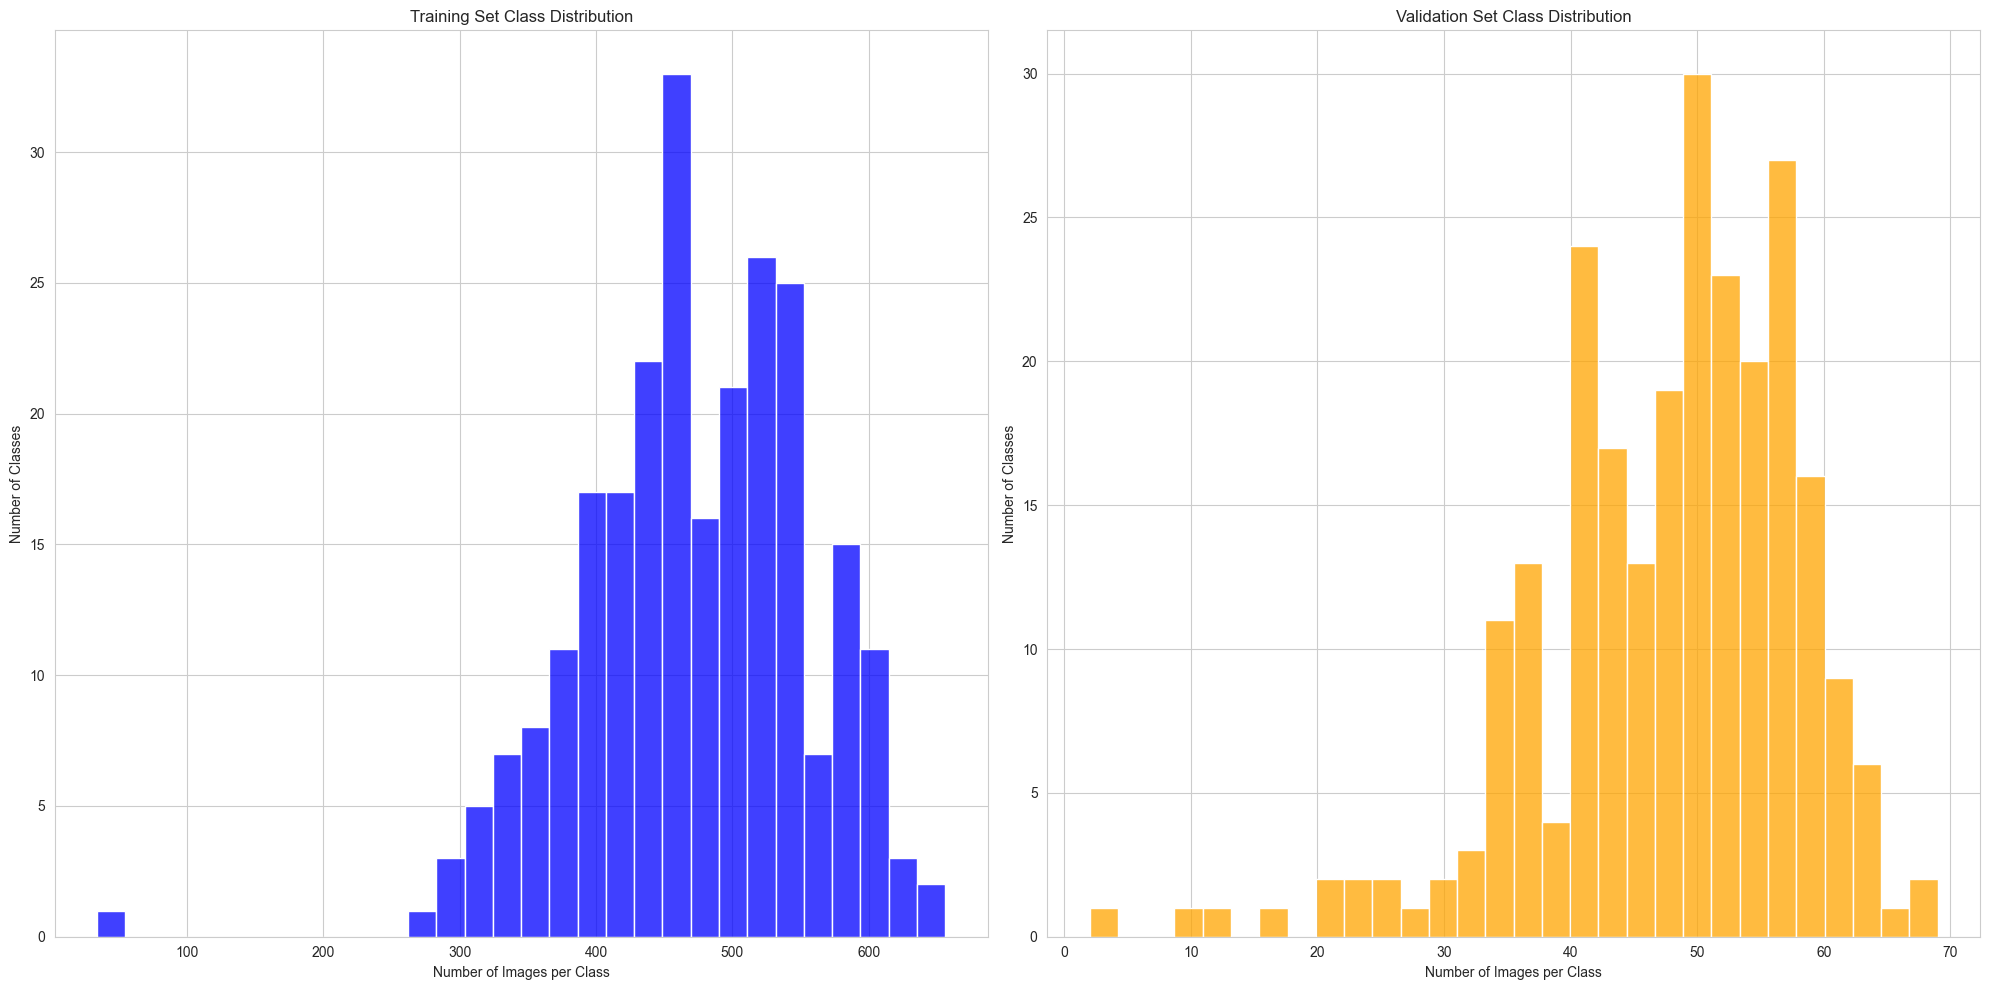

In [3]:
# Data files

from matplotlib import axes


train_cv = Path(DATA_DIR) / "train_labels.csv"
val_cv = Path(DATA_DIR) / "val_labels.csv"

print(f"Train directory: {train_cv}")
print(f"Validation directory: {val_cv}")

# Load training data
train_df = pd.read_csv(train_cv)
val_df = pd.read_csv(val_cv)

print(f"\nTrain Dataset Shape: {train_df.shape}")
print(f"\nValidation Dataset Shape: {val_df.shape}")

# Visualize class distribution in pie charts for both training and validation sets 
class_counts_train = train_df["label"].value_counts().sort_values()
class_counts_val = val_df["label"].value_counts().sort_values()


subplot_titles = ["Training Set Class Distribution", "Validation Set Class Distribution"]
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
# histograms
sns.histplot(class_counts_train, bins=30, ax=axes[0], color='blue')
sns.histplot(class_counts_val, bins=30, ax=axes[1], color='orange')
axes[0].set_title(subplot_titles[0])
axes[0].set_xlabel("Number of Images per Class")
axes[0].set_ylabel("Number of Classes")
axes[1].set_title(subplot_titles[1])
axes[1].set_xlabel("Number of Images per Class")
axes[1].set_ylabel("Number of Classes")
plt.tight_layout()
plt.show()

In [4]:
# Count the number images per class in both training and validation sets
num_images_per_class_train = train_df["label"].value_counts()
num_images_per_class_val = val_df["label"].value_counts()
# create a dataframe for the number of images per class
class_distribution_df = pd.DataFrame({
    "class": num_images_per_class_train.index,
    "train_count": num_images_per_class_train.values,
    "val_count": num_images_per_class_val.values
})
# sort the dataframe by the number of images in the training set
class_distribution_df = class_distribution_df.sort_values(by="train_count", ascending=False)
print("\nClass distribution (sorted by training set):")
display(class_distribution_df)


Class distribution (sorted by training set):


,class,train_count,val_count
0,218,656,69
1,147,636,67
2,155,635,65
3,0,633,64
4,117,617,64
...,...,...,...
246,103,300,21
247,83,290,17
248,164,289,11
249,213,277,9


In [5]:
import argparse
from codes.outlier_handler import run_outlier_pipeline

parser = argparse.ArgumentParser(description="Food-251 outlier detection pipeline")

parser.add_argument("--csv",         default="../dataset/train_labels.csv", help="Path to labels CSV")
parser.add_argument("--img_dir",     default="../dataset/train_set/",       help="Path to flat image folder")
parser.add_argument("--classes",     default=251, type=int,                 help="Number of classes")
parser.add_argument("--device",      default="mps",                         help="mps | cuda | cpu")


args, unknown = parser.parse_known_args()

df, stats_df, flagged_df, feats, image_ids, issues_df = run_outlier_pipeline(
    csv_path     = args.csv,
    img_dir      = args.img_dir,
    num_classes  = args.classes,
    device       = args.device,
)


Loaded: 118,475 images — 251 classes
────────────────────────────────────────────────────────────


[Stage 1] Integrity + blank audit: 100%|██████████| 118475/118475 [01:25<00:00, 1390.82it/s]



[Stage 1] Removed 217 / 118,475 images
reason
near_white      183
near_black       33
low_contrast      1
  → saved: removed_stage1_integrity.csv


[Stage 2] Non-food pixel stats: 100%|██████████| 118258/118258 [05:26<00:00, 361.74it/s]



[Stage 2] Flagged 9,011 / 118,258 images as potential non-food / background-only
  → saved: review_stage2_nonfood_pixelstats.csv
  ⚠  Inspect before removing — unusual-but-valid food shots may appear here


[Stage 3] Feature extraction: 100%|██████████| 1848/1848 [19:20<00:00,  1.59it/s]


[Stage 3] Running global IsolationForest for non-food detection...

[Stage 3] Flagged 5,913 global embedding outliers out of 118,258  (contamination=0.05)
  → saved: review_stage3_nonfood_embedding.csv
  ⚠  Inspect before removing — unusual-but-valid food shots may appear here

────────────────────────────────────────────────────────────
PIPELINE COMPLETE  (non-food + blank/background detection)
────────────────────────────────────────────────────────────
  Original images     : 118,475
  After Stage 1       : 118,258  (auto-removed blank/black/white/corrupt)
  Stage 2 review CSV  : review_stage2_nonfood_pixelstats.csv
  Stage 3 review CSV  : review_stage3_nonfood_embedding.csv

Visualise Stage 2 flagged images in context:
  plot_stage2_outlier_context(stats_df, flagged_df, label=<class_id>)
  plot_flagged_images(flagged_df, img_dir='train_set/')
  plot_flagged_images(embed_outlier_df, img_dir='train_set/', title='Stage 3')

Next step — after reviewing the CSVs:
  apply_review_decision

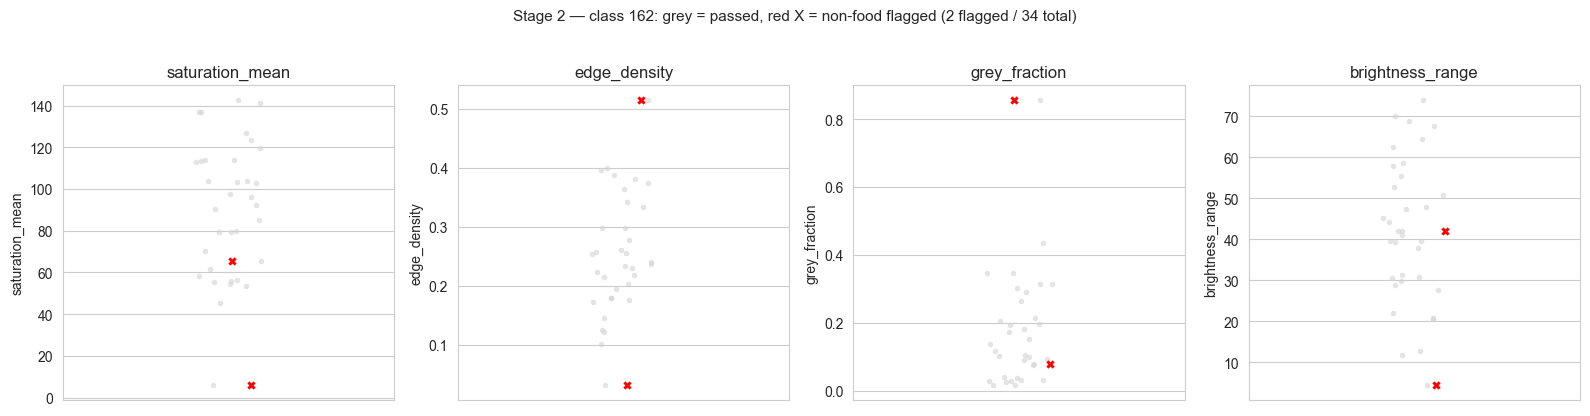

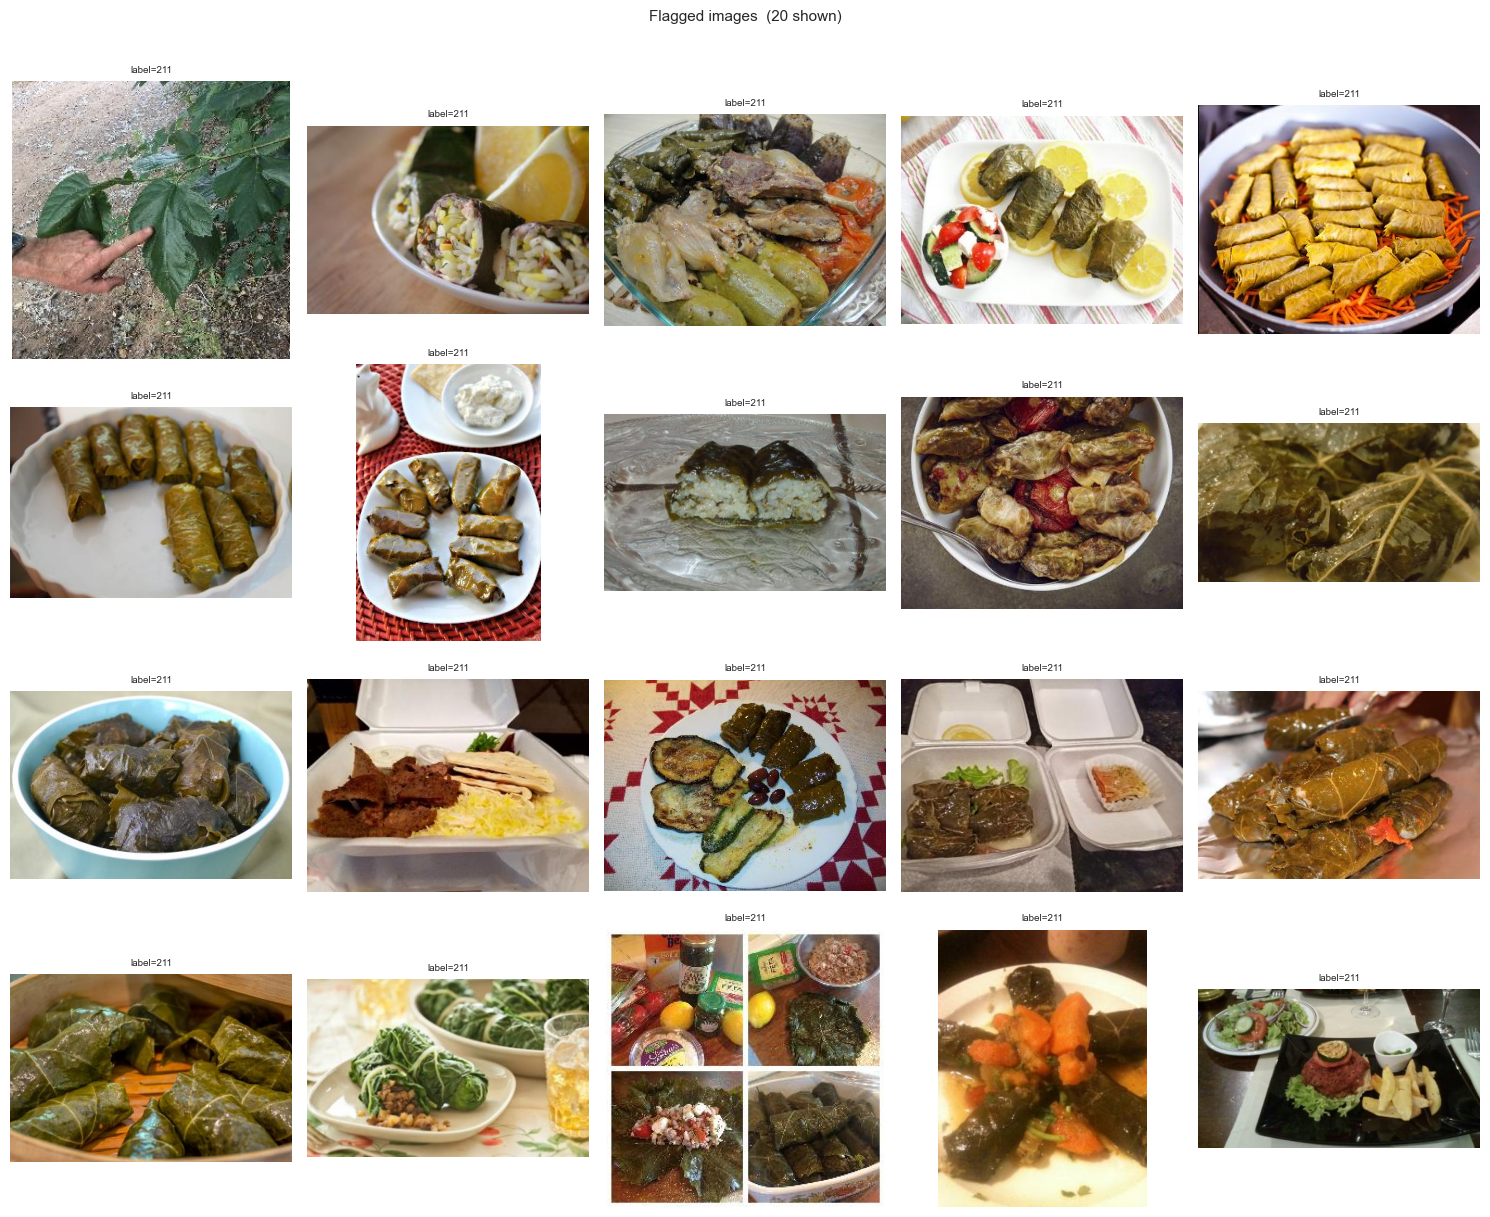

In [34]:
from codes.outlier_handler import plot_stage2_outlier_context, plot_flagged_images
plot_stage2_outlier_context(stats_df, flagged_df, 162)
plot_flagged_images(df, "../dataset/train_set")


In [33]:
outlier_df = pd.read_csv("../results/review_stage3_nonfood_embedding.csv")

# 1. count outliers per class
num_outlier_class = outlier_df["label"].value_counts()

# 2. build dataframe
outlier_class_dist = pd.DataFrame({
    "class": num_outlier_class.index,
    "outlier_count": num_outlier_class.values,
})

# 3. sort properly
outlier_class_dist = outlier_class_dist.sort_values(
    by="outlier_count",
    ascending=False
)

print("\nClass distribution (sorted by outlier count):")
display(outlier_class_dist)


Class distribution (sorted by outlier count):


,class,outlier_count
0,116,239
1,101,173
2,239,171
3,131,117
4,218,111
...,...,...
242,41,1
243,34,1
244,179,1
245,70,1
